<a href="https://colab.research.google.com/github/alyona-vishnoi/music-streaming-nba-rl/blob/main/03_ope_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OPE Evaluation — Offline Policy Evaluation for Music NBA

Using the Doubly Robust estimator to evaluate four policies
on the same offline logs.

This is the deployment gate: a policy only gets deployed
if its DR estimate clears the behavior policy's value.

Policies compared:
1. Random policy — uniform random action selection
2. Behavior policy — rule-based email-heavy system (notebook 1)
3. DQN offline — vanilla DQN trained on offline data (notebook 2)
4. CQL offline — conservative Q-learning (notebook 2)

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
import random
from collections import deque
import matplotlib.pyplot as plt
import pickle
from sklearn.linear_model import LinearRegression
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
states  = ['active_daily', 'active_weekly', 'lapsed_7d', 'lapsed_30d', 'churning']
actions = ['email_digest', 'push_notif', 'in_app_banner', 'new_mix', 'do_nothing']

state_idx  = {s: i for i, s in enumerate(states)}
action_idx = {a: i for i, a in enumerate(actions)}

state_dim  = len(states)
action_dim = len(actions)

def state_to_tensor(state):
    one_hot = torch.zeros(state_dim)
    one_hot[state_idx[state]] = 1.0
    return one_hot

# DQN network — identical to notebook 2
class DQN(nn.Module):
    def __init__(self, in_states, h1_nodes, out_actions):
        super().__init__()
        self.fc1 = nn.Linear(in_states, h1_nodes)
        self.out = nn.Linear(h1_nodes, out_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.out(x)
        return x

In [4]:
# load logs
with open('/content/drive/MyDrive/music_nba_logs.pkl', 'rb') as f:
    logs = pickle.load(f)

print(f"loaded {len(logs)} transitions")

# load CQL policy weights
cql_net = DQN(state_dim, 32, action_dim)
cql_net.load_state_dict(torch.load('/content/drive/MyDrive/cql_music_policy.pt'))
cql_net.eval()
print("CQL policy loaded")

# load DQN policy
dqn_net = DQN(state_dim, 32, action_dim)
dqn_net.load_state_dict(torch.load('/content/drive/MyDrive/dqn_music_policy.pt'))
dqn_net.eval()
print("DQN policy loaded")

loaded 50000 transitions
CQL policy loaded
DQN policy loaded


In [5]:
# policy 1 — random
def random_policy(state):
    prob = 1.0 / action_dim
    return {a: prob for a in actions}

# policy 2 — behavior policy (same as notebook 1)
def behavior_policy(state):
    if state == 'active_daily':
        probs = {'email_digest': 0.2, 'push_notif': 0.15,
                 'in_app_banner': 0.4, 'new_mix': 0.2, 'do_nothing': 0.05}
    elif state == 'active_weekly':
        probs = {'email_digest': 0.35, 'push_notif': 0.2,
                 'in_app_banner': 0.25, 'new_mix': 0.15, 'do_nothing': 0.05}
    elif state == 'lapsed_7d':
        probs = {'email_digest': 0.5, 'push_notif': 0.2,
                 'in_app_banner': 0.1, 'new_mix': 0.1, 'do_nothing': 0.1}
    elif state == 'lapsed_30d':
        probs = {'email_digest': 0.25, 'push_notif': 0.25,
                 'in_app_banner': 0.15, 'new_mix': 0.25, 'do_nothing': 0.1}
    else:  # churning
        probs = {'email_digest': 0.25, 'push_notif': 0.25,
                 'in_app_banner': 0.15, 'new_mix': 0.25, 'do_nothing': 0.1}
    return probs

# policy 3 — DQN (softmax over Q values)
def dqn_policy(state):
    s_t    = state_to_tensor(state).unsqueeze(0)
    with torch.no_grad():
        q_vals = dqn_net(s_t).squeeze(0)
    probs  = F.softmax(q_vals, dim=0).numpy()
    return {a: float(probs[i]) for i, a in enumerate(actions)}

# policy 4 — CQL (softmax over Q values)
def cql_policy(state):
    s_t    = state_to_tensor(state).unsqueeze(0)
    with torch.no_grad():
        q_vals = cql_net(s_t).squeeze(0)
    probs  = F.softmax(q_vals, dim=0).numpy()
    return {a: float(probs[i]) for i, a in enumerate(actions)}

In [7]:
test_state = 'lapsed_30d'
print(f"state: {test_state}\n")

for name, policy in [('random', random_policy),
                     ('behavior', behavior_policy),
                     ('DQN', dqn_policy),
                     ('CQL', cql_policy)]:
    probs = policy(test_state)
    best  = max(probs, key=probs.get)
    print(f"{name:10s} -> best: {best:15s} | probs: { {a: round(p,3) for a,p in probs.items()} }")

state: lapsed_30d

random     -> best: email_digest    | probs: {'email_digest': 0.2, 'push_notif': 0.2, 'in_app_banner': 0.2, 'new_mix': 0.2, 'do_nothing': 0.2}
behavior   -> best: email_digest    | probs: {'email_digest': 0.25, 'push_notif': 0.25, 'in_app_banner': 0.15, 'new_mix': 0.25, 'do_nothing': 0.1}
DQN        -> best: new_mix         | probs: {'email_digest': 0.219, 'push_notif': 0.164, 'in_app_banner': 0.143, 'new_mix': 0.307, 'do_nothing': 0.166}
CQL        -> best: new_mix         | probs: {'email_digest': 0.251, 'push_notif': 0.222, 'in_app_banner': 0.156, 'new_mix': 0.263, 'do_nothing': 0.108}


In [9]:
def build_reward_model(logs):
    """
    Train reward model on logs.
    Features: one-hot state (5) + one-hot action (5) = 10 features
    Target: reward_ltv
    """
    X = []
    y = []

    for _, row in logs.iterrows():
        # one-hot encode state
        state_vec  = [0] * state_dim
        state_vec[state_idx[row['state']]] = 1

        # one-hot encode action
        action_vec = [0] * action_dim
        action_vec[action_idx[row['action']]] = 1

        X.append(state_vec + action_vec)
        y.append(row['reward_ltv'])

    X = np.array(X)
    y = np.array(y)

    model = LinearRegression()
    model.fit(X, y)
    print(f"reward model trained on {len(X)} rows")
    print(f"R^2 score: {model.score(X, y):.4f}")
    return model

reward_model = build_reward_model(logs)

reward model trained on 50000 rows
R^2 score: 0.1986


In [10]:
def doubly_robust(logs, eval_policy_fn, model):
    dr_values = []

    for _, row in logs.iterrows():
        state = row['state']
        action = row['action']
        reward = row['reward_ltv']
        propensity = row['propensity']

        probs = eval_policy_fn(state)
        pi_e = probs[action]
        w = pi_e / propensity

        # dm_component — expected reward under eval policy
        dm_component = 0
        for a, prob in probs.items():
            state_vec  = [0] * state_dim
            state_vec[state_idx[state]] = 1
            action_vec = [0] * action_dim
            action_vec[action_idx[a]] = 1
            x = np.array([state_vec + action_vec])
            dm_component += prob * model.predict(x)[0]

        # model prediction for logged action
        state_vec = [0] * state_dim
        state_vec[state_idx[state]] = 1
        action_vec = [0] * action_dim
        action_vec[action_idx[action]] = 1
        x = np.array([state_vec + action_vec])
        actual_pred = model.predict(x)[0]

        # IPS correction
        correction = w * (reward - actual_pred)

        dr_values.append(dm_component + correction)

    return np.mean(dr_values)

In [11]:
print("evaluating all four policies with DR estimator...")

dr_random = doubly_robust(logs, random_policy, reward_model)
dr_behavior = doubly_robust(logs, behavior_policy, reward_model)
dr_dqn = doubly_robust(logs, dqn_policy, reward_model)
dr_cql = doubly_robust(logs, cql_policy, reward_model)

print(f"{'='*45}")
print(f"{'policy':12s} {'DR estimate':>12s}")
print(f"{'='*45}")
print(f"{'random':12s} {dr_random:>12.4f}")
print(f"{'behavior':12s} {dr_behavior:>12.4f}")
print(f"{'DQN':12s} {dr_dqn:>12.4f}")
print(f"{'CQL':12s} {dr_cql:>12.4f}")
print(f"{'='*45}")

# deployment gate
print(f"\ndeployment gate (must beat behavior policy):")
print(f"  DQN clears bar: {dr_dqn > dr_behavior}")
print(f"  CQL clears bar: {dr_cql > dr_behavior}")

evaluating all four policies with DR estimator...
(this takes a minute — 50k rows × 4 policies)

policy        DR estimate
random             0.0446
behavior           0.0370
DQN                0.0559
CQL                0.0405

deployment gate (must beat behavior policy):
  DQN clears bar: True
  CQL clears bar: True


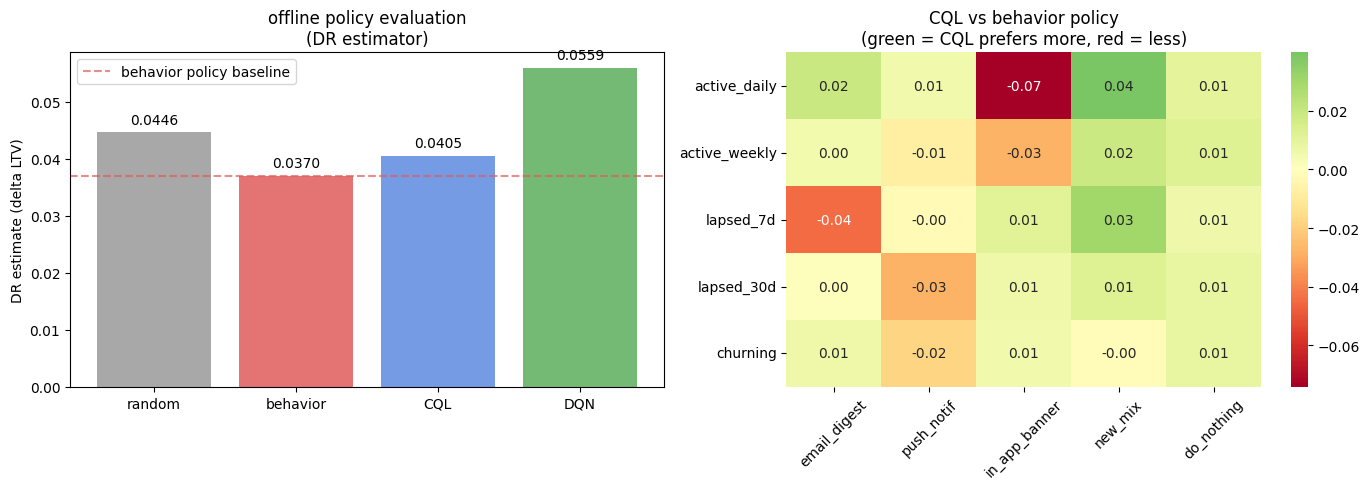

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot 1 — DR estimates comparison
policy_names = ['random', 'behavior', 'CQL', 'DQN']
dr_values = [dr_random, dr_behavior, dr_cql, dr_dqn]
colors = ['#999999', '#E05C5C', '#5C8AE0', '#5CAE5C']

bars = axes[0].bar(policy_names, dr_values, color=colors, alpha=0.85)
axes[0].axhline(dr_behavior, color='#E05C5C', linestyle='--',
                alpha=0.7, label='behavior policy baseline')
axes[0].set_ylabel('DR estimate (delta LTV)')
axes[0].set_title('offline policy evaluation\n(DR estimator)')
axes[0].legend()

# add value labels on bars
for bar, val in zip(bars, dr_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# plot 2 — learned policy heatmap (CQL vs behavior)
import seaborn as sns

cql_policy_matrix = np.zeros((len(states), len(actions)))
behavior_policy_matrix = np.zeros((len(states), len(actions)))

for i, state in enumerate(states):
    cql_probs = cql_policy(state)
    behavior_probs = behavior_policy(state)
    for j, action in enumerate(actions):
        cql_policy_matrix[i, j] = cql_probs[action]
        behavior_policy_matrix[i, j] = behavior_probs[action]

# difference matrix — positive = CQL prefers this more than behavior
diff_matrix = cql_policy_matrix - behavior_policy_matrix

sns.heatmap(diff_matrix,
            xticklabels=actions,
            yticklabels=states,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            ax=axes[1])
axes[1].set_title('CQL vs behavior policy\n(green = CQL prefers more, red = less)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
# save DR results
results = {
    'dr_random': dr_random,
    'dr_behavior': dr_behavior,
    'dr_dqn': dr_dqn,
    'dr_cql': dr_cql,
}

with open('/content/drive/MyDrive/ope_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("results saved")

results saved
